<a href="https://colab.research.google.com/github/Sara-Qassimi/RS_code/blob/colab/Content_Based_Recommender_System_and_Evaluating_Accuracy_Metrics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

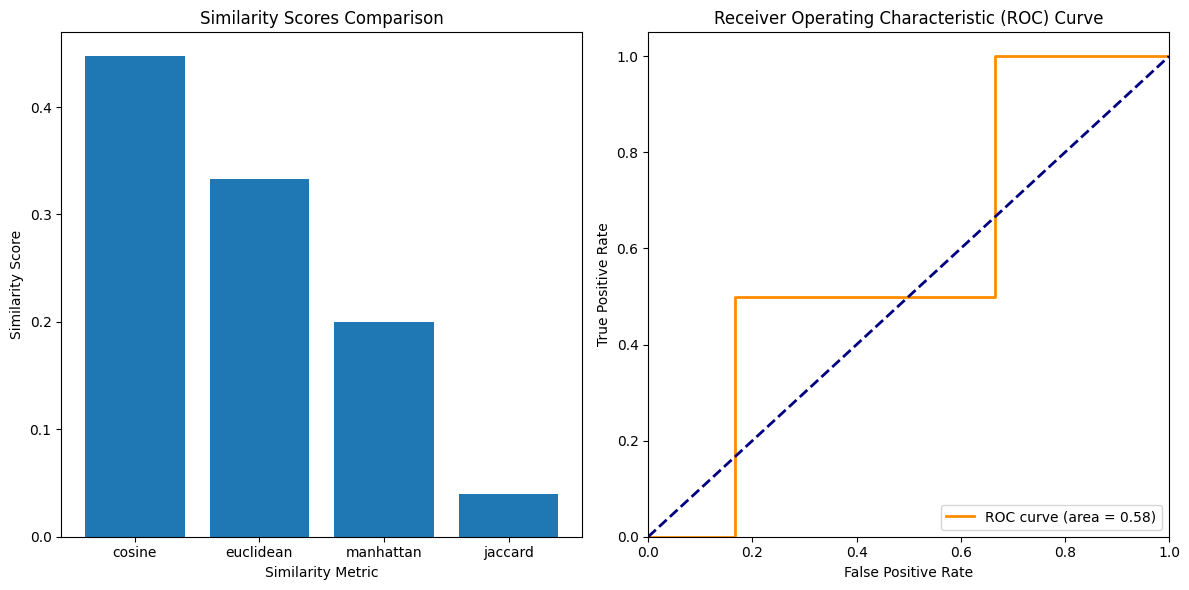

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import jaccard_score

# Generate a sample dataset
np.random.seed(42)
num_rows = 10
num_features = 5
data = np.random.randint(0, 2, size=(num_rows, num_features))  # Generate random binary data
df = pd.DataFrame(data, columns=['action', 'romance', 'horror', 'fantasy', 'drama'])  # Create a DataFrame with column names

# Build Item-profile in vector form
item_profile = df.values  # Convert DataFrame to numpy array

# Infer User-profile
user_profiles = []
for user in range(num_rows):
    user_profile = np.mean(item_profile[:user+1], axis=0)  # Compute average of item profiles for each user
    user_profiles.append(user_profile)
user_profiles = np.array(user_profiles)  # Convert user profiles to numpy array

# Calculate different similarity metrics
def calculate_cosine_similarity(user_profile, item_profile):
    dot_product = np.dot(user_profile, item_profile)  # Compute dot product of user and item profiles
    magnitude_user = np.sqrt(np.sum(user_profile ** 2))  # Compute magnitude of user profile vector
    magnitude_item = np.sqrt(np.sum(item_profile ** 2))  # Compute magnitude of item profile vector
    return dot_product / (magnitude_user * magnitude_item)  # Calculate cosine similarity

similarity_metrics = ['cosine', 'euclidean', 'manhattan', 'jaccard']  # List of similarity metrics to calculate
user_id = 0  # Index of user profile
item_id = 5  # Index of item profile

similarity_scores = {}

for metric in similarity_metrics:
    if metric == 'cosine':
        similarity_scores[metric] = calculate_cosine_similarity(user_profiles[user_id], item_profile[item_id])  # Calculate cosine similarity using custom function
    elif metric == 'euclidean':
        similarity_scores[metric] = 1 / (1 + euclidean_distances([user_profiles[user_id]], [item_profile[item_id]])[0][0])  # Calculate euclidean similarity
    elif metric == 'manhattan':
        similarity_scores[metric] = 1 / (1 + manhattan_distances([user_profiles[user_id]], [item_profile[item_id]])[0][0])  # Calculate manhattan similarity
    elif metric == 'jaccard':
        similarity_scores[metric] = jaccard_score(user_profiles[user_id], item_profile[item_id], average='weighted')  # Calculate Jaccard similarity

# Calculate accuracy metrics and ROC curve
labels = np.random.randint(0, 2, size=num_rows)  # Generate random binary labels
predictions = np.random.rand(num_rows)  # Generate random predictions

precision = precision_score(labels, predictions.round())  # Calculate precision
recall = recall_score(labels, predictions.round())  # Calculate recall
f1 = f1_score(labels, predictions.round())  # Calculate F1-score

fpr, tpr, _ = roc_curve(labels, predictions)  # Calculate ROC curve
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# Plotting
plt.figure(figsize=(12, 6))  # Create a figure with specified size

# Similarity scores comparison subplot
plt.subplot(1, 2, 1)  # Create a subplot
plt.bar(similarity_scores.keys(), similarity_scores.values())  # Create a bar plot
plt.xlabel('Similarity Metric')  # X-axis label
plt.ylabel('Similarity Score')  # Y-axis label
plt.title('Similarity Scores Comparison')  # Title of the subplot

# ROC curve subplot
plt.subplot(1, 2, 2)  # Create another subplot
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)  # Plot ROC curve
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Plot diagonal line
plt.xlim([0.0, 1.0])  # X-axis limits
plt.ylim([0.0, 1.05])  # Y-axis limits
plt.xlabel('False Positive Rate')  # X-axis label
plt.ylabel('True Positive Rate')  # Y-axis label
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Title of the subplot
plt.legend(loc="lower right")  # Add legend

plt.tight_layout()  # Adjust layout
plt.show()  # Show the plots
